# Olist E-commerce Analysis

This notebook presents the visualization layer of the project based on SQL outputs exported to CSV.

The objective is to analyze:

- How revenue is generated  
- Which customer segments drive it  
- Where customer experience issues are hidden  

👉 The key question:

**Are high-performing categories truly healthy, or are they hiding customer satisfaction problems?**

---

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Revenue Trend

We start by analyzing monthly revenue evolution to understand the overall commercial trajectory of the business.

Since the dataset ends in mid-September 2018, incomplete final months are excluded to avoid distorted monthly comparisons.

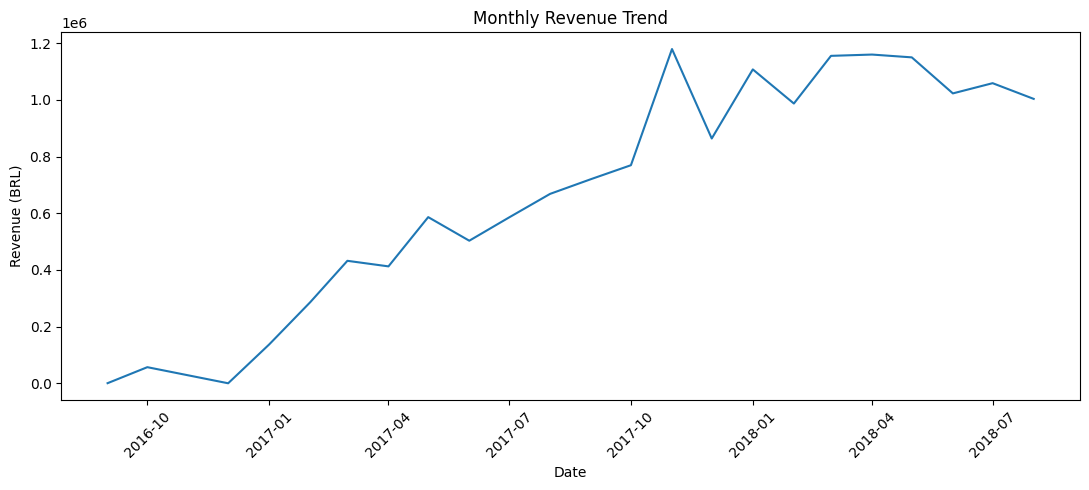

In [10]:
df_revenue = pd.read_csv("../data/revenue_over_time.csv")

df_revenue["date"] = pd.to_datetime(
    df_revenue["year"].astype(str) + "-" + df_revenue["month"].astype(str) + "-01"
)

df_revenue = df_revenue.sort_values("date")

# Exclude incomplete final months to keep monthly comparisons consistent
df_revenue = df_revenue[df_revenue["date"] < "2018-09-01"]

plt.figure(figsize=(11, 5))
plt.plot(df_revenue["date"], df_revenue["revenue"])

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../outputs/charts/revenue_over_time.png")
plt.show()

The chart shows a strong upward revenue trajectory from 2017 onward, followed by a more stable high-revenue period in 2018.

This first view suggests sustained marketplace growth and provides the business context for the deeper segment and customer experience analyses that follow.

---

## 2. Pareto Analysis

We analyze how revenue is distributed across product categories to identify concentration patterns.

The Pareto principle (80/20 rule) suggests that a small number of categories typically generate the majority of total revenue.

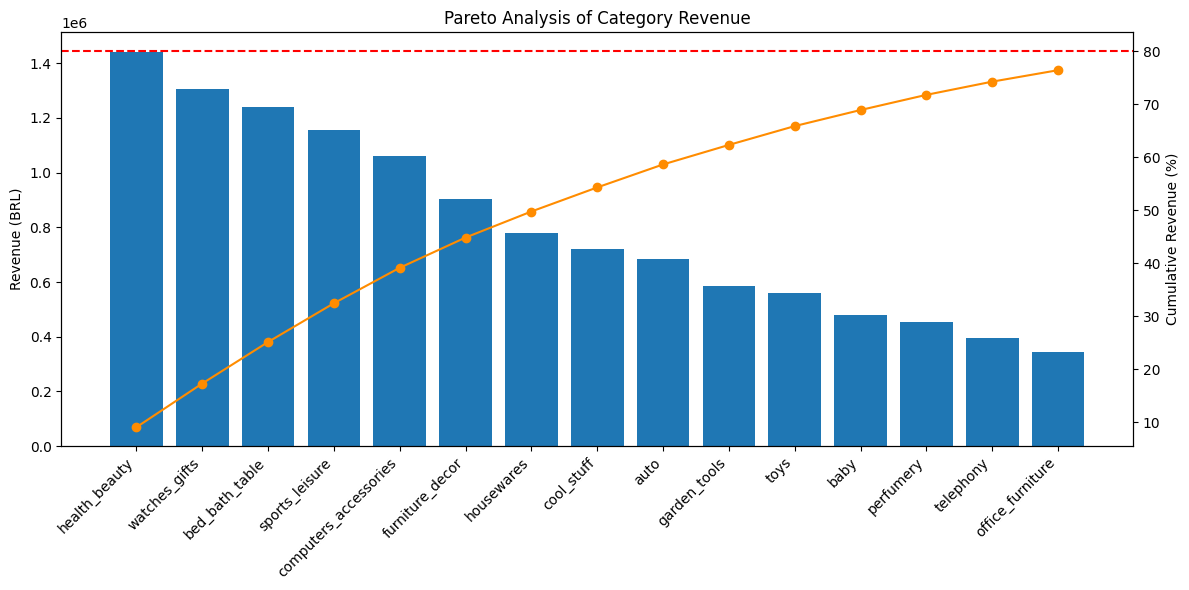

In [11]:
df_pareto = pd.read_csv("../data/pareto.csv")

# Focus on top categories for better readability
df_pareto_top = df_pareto.head(15)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_pareto_top["category"], df_pareto_top["revenue"])
ax1.set_ylabel("Revenue (BRL)")

ax2 = ax1.twinx()
ax2.plot(
    df_pareto_top["category"],
    df_pareto_top["cum_pct_revenue"],
    color="darkorange",
    marker="o"
)
ax2.set_ylabel("Cumulative Revenue (%)")

# 80% Pareto threshold
ax2.axhline(80, linestyle="--", color="red")

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

plt.title("Pareto Analysis of Category Revenue")

plt.tight_layout()
plt.savefig("../outputs/charts/pareto_revenue.png")
plt.show()

The chart shows a clear revenue concentration pattern.

A relatively small number of categories contributes to a large share of total revenue, confirming the Pareto distribution.

This insight helps prioritize high-impact categories for further analysis, especially when evaluating customer experience issues.

---

## 3. Customer Segmentation

Customers are segmented using the RFM framework (Recency, Frequency, Monetary) to understand how value is distributed across the customer base.

For visualization clarity, only the most representative segments are shown, excluding low-volume groups.

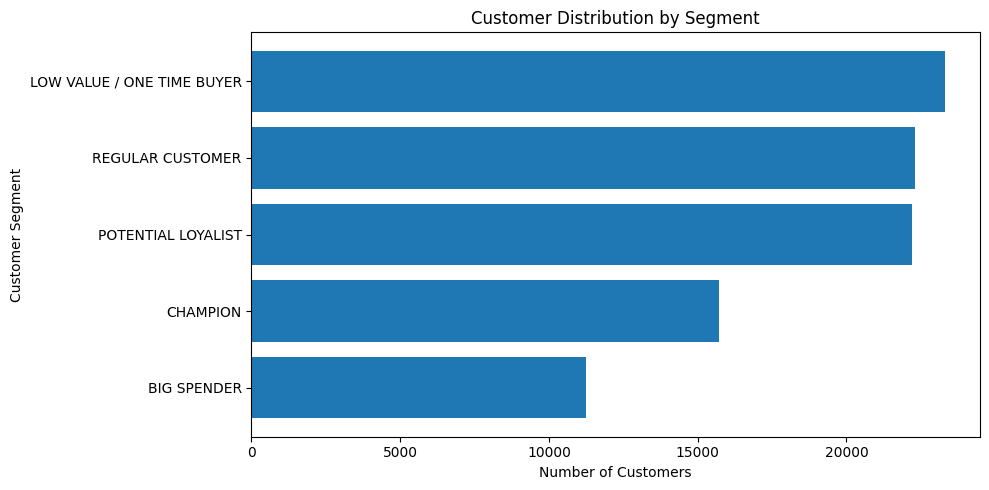

In [12]:
df_rfm = pd.read_csv("../data/segment_revenue_distribution.csv")

df_rfm_filtered = df_rfm[
    df_rfm["customer_segment"].isin([
        "BIG SPENDER",
        "CHAMPION",
        "REGULAR CUSTOMER",
        "POTENTIAL LOYALIST",
        "LOW VALUE / ONE TIME BUYER"
    ])
]

# Sort segments by customer count for better readability
df_rfm_filtered = df_rfm_filtered.sort_values("customer_count")

plt.figure(figsize=(10, 5))

plt.barh(
    df_rfm_filtered["customer_segment"],
    df_rfm_filtered["customer_count"]
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.savefig("../outputs/charts/rfm_customer_distribution.png")
plt.show()

Most customers belong to lower-value segments, such as "Low Value / One Time Buyer" and "Potential Loyalist".

High-value segments like "Champion" and "Big Spender" represent a smaller portion of the customer base.

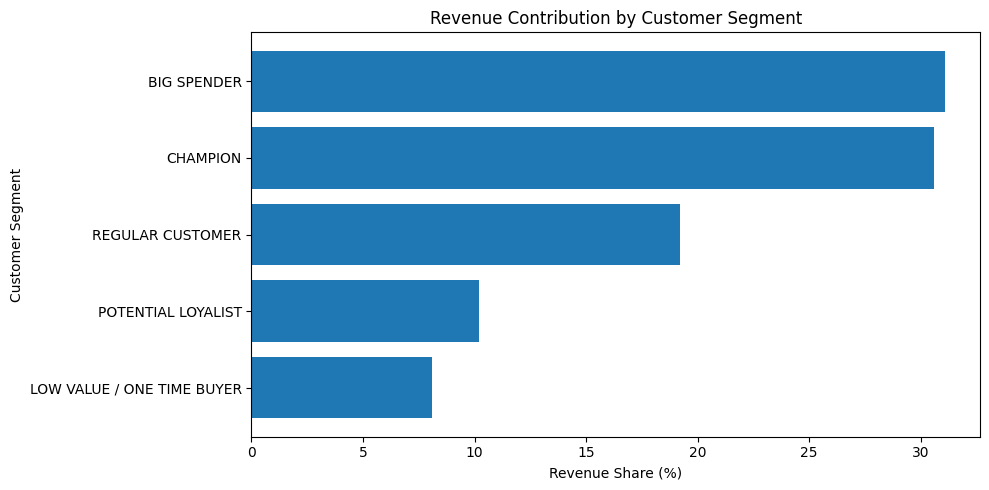

In [13]:
# Sort segments by revenue contribution
df_rfm_filtered = df_rfm_filtered.sort_values("revenue_share_pct")

plt.figure(figsize=(10, 5))

plt.barh(
    df_rfm_filtered["customer_segment"],
    df_rfm_filtered["revenue_share_pct"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue Share (%)")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.savefig("../outputs/charts/rfm_revenue_share.png")
plt.show()

Despite being fewer in number, "Big Spender" and "Champion" customers contribute a disproportionately large share of total revenue.

This highlights a strong value concentration, where a small group of customers drives a significant portion of business performance.

---

## 4. Revenue vs Customer Satisfaction

We analyze the relationship between category-level revenue and customer satisfaction.

The goal is to identify categories that generate high revenue but show below-average review scores, indicating potential hidden risks.

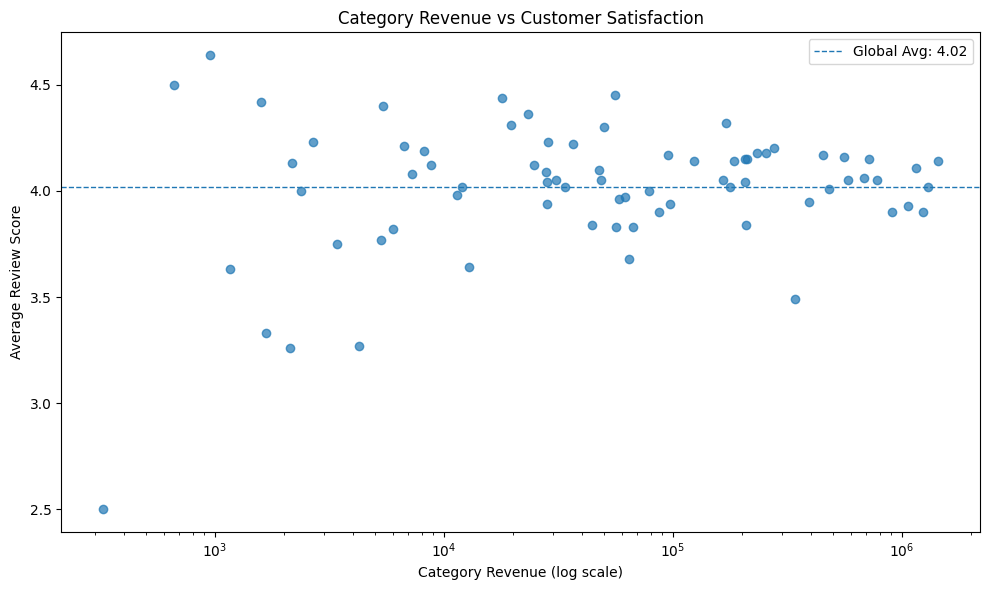

In [14]:
df_experience = pd.read_csv("../data/category_experience.csv")

mean_review_score = df_experience["avg_review_score"].mean()

plt.figure(figsize=(10, 6))

plt.scatter(
    df_experience["revenue"],
    df_experience["avg_review_score"],
    alpha=0.7
)

plt.axhline(
    mean_review_score,
    linestyle="--",
    linewidth=1,
    label=f"Global Avg: {mean_review_score:.2f}"
)

plt.xscale("log")

plt.title("Category Revenue vs Customer Satisfaction")
plt.xlabel("Category Revenue (log scale)")
plt.ylabel("Average Review Score")

plt.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/category_revenue_vs_average_review.png")
plt.show()

Revenue distribution is highly skewed, which is why a logarithmic scale is used for better visualization.

The horizontal line represents the global average review score, allowing us to quickly identify categories below the average.

Several high-revenue categories fall below this threshold, suggesting that strong commercial performance may be masking underlying customer experience issues.

---

## 5. Champions vs Big Spenders

We compare category-level revenue share between high-value customer segments.

The goal is to identify differences in purchasing behavior between "Champions" and "Big Spenders", highlighting which categories are more dominant for each group.

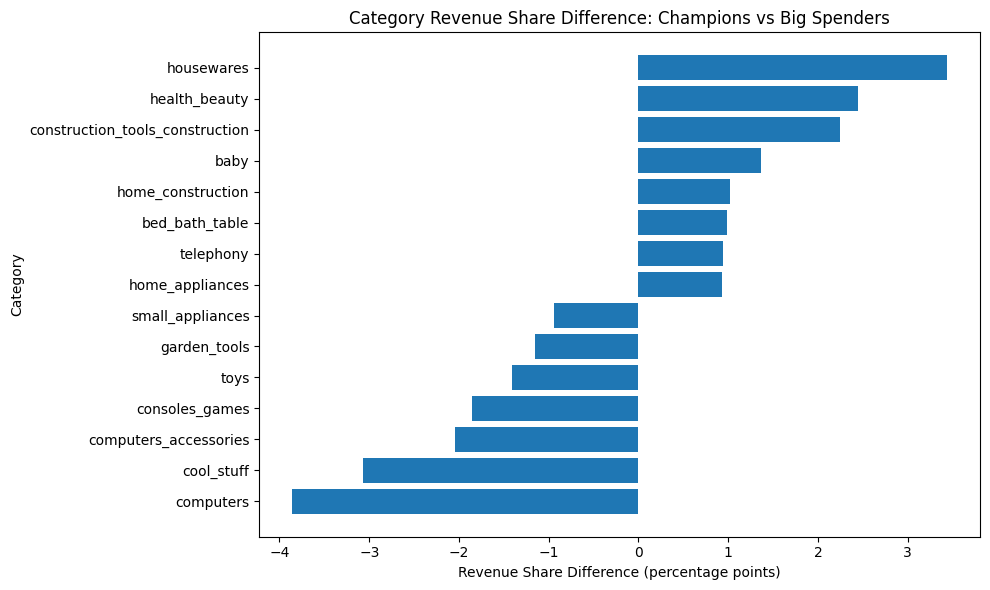

In [15]:
df_category_comparison = pd.read_csv("../data/category_comparison.csv")

df_category_comparison_top = (
    df_category_comparison
    .sort_values("abs_difference_pct", ascending=False)
    .head(15)
    .sort_values("difference_pct")
)

plt.figure(figsize=(10, 6))

plt.barh(
    df_category_comparison_top["category"],
    df_category_comparison_top["difference_pct"]
)

plt.title("Category Revenue Share Difference: Champions vs Big Spenders")
plt.xlabel("Revenue Share Difference (percentage points)")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("../outputs/charts/category_comparison.png")
plt.show()

Positive values indicate categories where "Champions" contribute a higher share of revenue.

Negative values indicate categories where "Big Spenders" are more dominant.

The results reveal clear behavioral differences:

- Champions tend to concentrate more on home and lifestyle-related categories  
- Big Spenders show stronger presence in tech and discretionary categories  

This highlights that not all high-value customers behave the same, which has implications for targeting, personalization, and product strategy.

---

## 6. Root Cause Analysis

We analyze customer review feedback for a high-revenue, low-satisfaction product to identify the main drivers of poor customer experience.

The goal is to move from aggregated metrics to concrete, actionable issues.

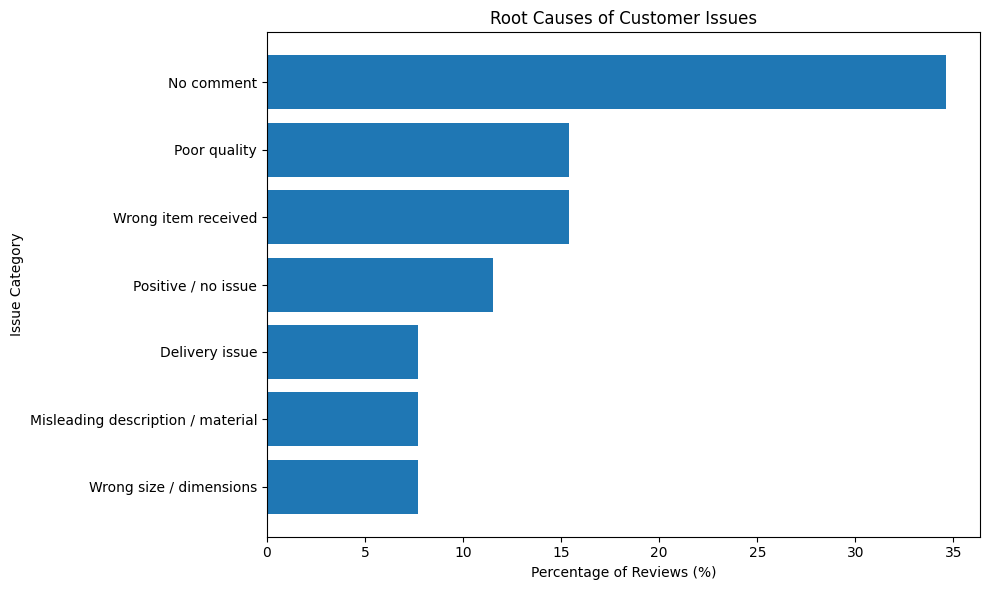

In [16]:
df_issues = pd.read_csv("../data/product_issues.csv")

# Create readable labels for visualization
issue_labels = {
    "no_comment": "No comment",
    "poor_quality": "Poor quality",
    "positive_or_no_issue": "Positive / no issue",
    "delivery_issue": "Delivery issue",
    "wrong_size_or_dimensions": "Wrong size / dimensions",
    "misleading_description_or_material": "Misleading description / material",
    "wrong_item_received": "Wrong item received"
}

df_issues["issue_label"] = df_issues["issue_category"].map(issue_labels)

# Sort for better visualization
df_issues = df_issues.sort_values("pct_of_total_reviews")


plt.figure(figsize=(10, 6))

plt.barh(
    df_issues["issue_label"],
    df_issues["pct_of_total_reviews"]
)

plt.title("Root Causes of Customer Issues")
plt.xlabel("Percentage of Reviews (%)")
plt.ylabel("Issue Category")

plt.tight_layout()
plt.savefig("../outputs/charts/product_issues.png")
plt.show()

The issue distribution suggests that poor customer experience is mainly linked to product quality problems, wrong items, misleading descriptions, and delivery issues.

A large share of reviews contains no written comment, which reduces the level of detail available for root cause interpretation.

Even with this limitation, the analysis supports the broader conclusion of the project: strong commercial performance can coexist with clear customer experience problems.

---